In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from scipy.optimize import minimize

In [34]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [35]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data = pd.read_csv(file_path, header=None)
spectrum_50 = data[0].values
t_50 = 4279386 # 50 days exposure
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev>=0) & (E_kev <= 3000)
E_kev = E_kev[mask]
spectrum_50 = spectrum_50[mask]

In [36]:
t_50 /( (24*60*60))


49.52993055555555

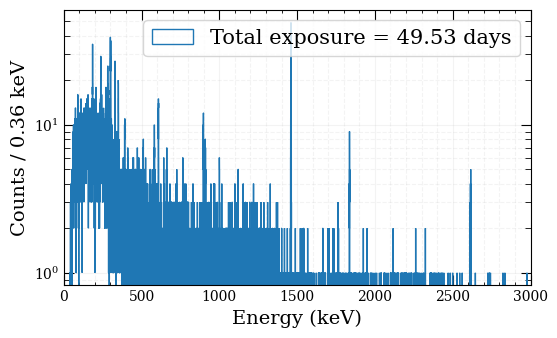

In [46]:
plt.figure()
ax = plt.gca()


dx_major = 500
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

#bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/56))
bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)))
counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spectrum_50,   
                               histtype='step',
                               label=f'Total exposure = {t_50 /(24*60*60):.2f} days')
db = bin_edge[1]- bin_edge[0]



plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db:.2f} keV')
plt.xlim(0, 3000)
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

plt.savefig("spectrum_50_days.png")
plt.show()